<a href="https://colab.research.google.com/github/AnikKushwaha/AnikKushwaha/blob/master/job%20work3_a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install deepface opencv-python matplotlib seaborn scikit-learn joblib


In [16]:
import os
import cv2
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from deepface import DeepFace
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_lfw_people
from joblib import dump, load


In [6]:
face_data = fetch_lfw_people(min_faces_per_person=20)
face_images = face_data.images
face_labels = face_data.target
name_list = face_data.target_names
print(f" Face Samples: {len(face_images)}")
print(f" Individuals: {len(name_list)}")

 Total Face Samples: 3023
 Unique Individuals: 62


In [7]:
print(" Extracting facial features...")
face_features = []
for picture in face_images:
    rgb_frame = cv2.cvtColor(picture, cv2.COLOR_GRAY2RGB)

    embedding_info = DeepFace.represent(
        img_path=rgb_frame,
        model_name="ArcFace",
        enforce_detection=False
    )
    face_features.append(embedding_info[0]["embedding"])
face_features = np.array(face_features)
print(" Feature Extraction Complete!")
print(" Embedding Vector Shape:", face_features.shape)


 Extracting facial features...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/arcface_weights.h5
To: /root/.deepface/weights/arcface_weights.h5


25-11-10 06:28:07 - 🔗 arcface_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/arcface_weights.h5 to /root/.deepface/weights/arcface_weights.h5...


100%|██████████| 137M/137M [00:00<00:00, 401MB/s]


 Feature Extraction Complete!
 Embedding Vector Shape: (3023, 512)


In [8]:
from sklearn.model_selection import StratifiedShuffleSplit

data_split = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

for train_ids, test_ids in data_split.split(face_features, face_labels):
    feat_train, feat_test = face_features[train_ids], face_features[test_ids]
    label_train, label_test = face_labels[train_ids], face_labels[test_ids]


In [9]:
from sklearn.preprocessing import StandardScaler

normalizer = StandardScaler()

train_scaled = normalizer.fit_transform(feat_train)
test_scaled = normalizer.transform(feat_test)


In [10]:
svm_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    probability=True
)
svm_model.fit(train_scaled, label_train)


SVC(C=10, probability=True)

In [11]:
test_predictions = svm_model.predict(test_scaled)

model_score = accuracy_score(label_test, test_predictions)
print(f"\n Recognition Accuracy: {model_score * 100:.2f}%\n")

print("Performance Summary:")
print(classification_report(label_test, test_predictions, target_names=name_list))



 Recognition Accuracy: 49.75%

Performance Summary:
                           precision    recall  f1-score   support

         Alejandro Toledo       0.50      0.12      0.20         8
             Alvaro Uribe       0.33      0.29      0.31         7
          Amelie Mauresmo       1.00      0.25      0.40         4
             Andre Agassi       0.43      0.43      0.43         7
           Angelina Jolie       0.00      0.00      0.00         4
             Ariel Sharon       0.37      0.44      0.40        16
    Arnold Schwarzenegger       0.00      0.00      0.00         8
     Atal Bihari Vajpayee       0.43      0.60      0.50         5
             Bill Clinton       0.75      0.50      0.60         6
             Carlos Menem       0.33      0.25      0.29         4
             Colin Powell       0.59      0.77      0.67        47
            David Beckham       1.00      0.17      0.29         6
          Donald Rumsfeld       0.47      0.58      0.52        24
        

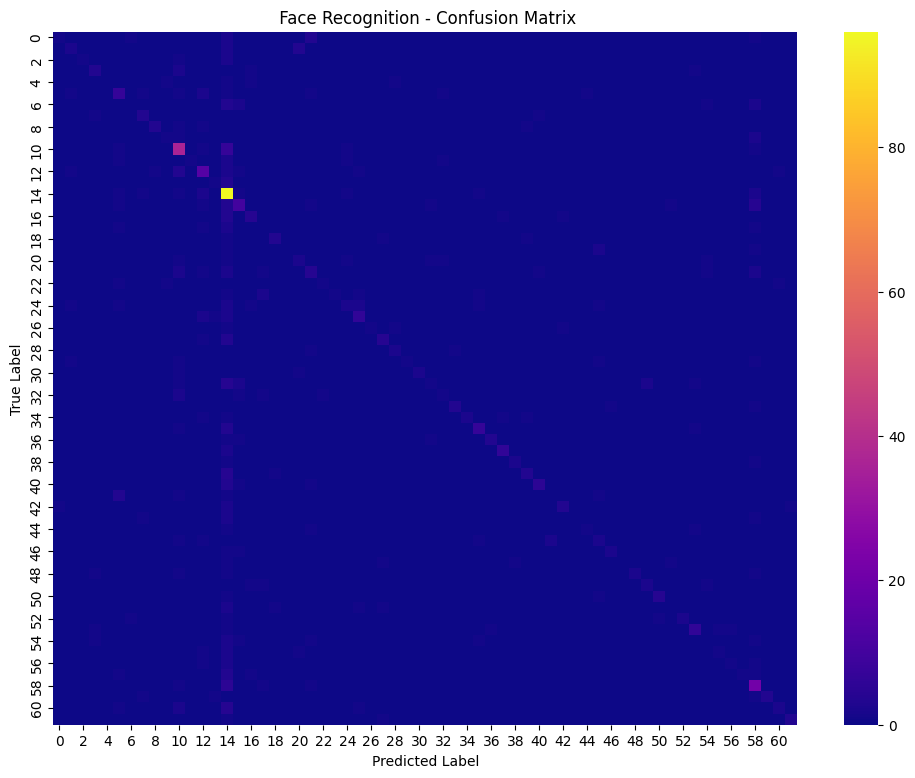

In [12]:
conf_matrix = confusion_matrix(label_test, test_predictions)

plt.figure(figsize=(12, 9))
sns.heatmap(conf_matrix, annot=False, cmap="plasma")

plt.title(" Face Recognition - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [13]:
dump(svm_model, "face_model.joblib")
dump(normalizer, "feature_normalizer.joblib")

np.save("saved_labels.npy", face_labels)

print(" Model and preprocessing resources have been successfully stored!")


 Model and preprocessing resources have been successfully stored!


In [15]:
def identify_face(image_location):
    trained_model = load("face_model.joblib")
    loaded_scaler = load("feature_normalizer.joblib")

    input_image = cv2.imread(image_location)

    feature_data = DeepFace.represent(
        img_path=input_image,
        model_name="Facenet512",
        enforce_detection=False
    )

    processed_feature = np.array(
        feature_data[0]["embedding"]
    ).reshape(1, -1)

    processed_feature = loaded_scaler.transform(processed_feature)

    predicted_label = trained_model.predict(processed_feature)[0]

    return name_list[predicted_label]
